In [1]:
from matplotlib import pyplot as plt
from pathlib import Path


import sys
sys.path.append('/grid/kinney/data/desmara/pacbio_regex_parser/bin')

from cluster_on_alignment import build_alignment_df, make_alignment_matrix, plot_pca_hexbin, plot_clustermap

In [2]:
bam_path = Path("/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/aligning/bc2011.lib001_rotated.subsampled_10000.minimap2_lowNscore_aligned.sorted.bam")
alignment_df = build_alignment_df(bam_path, seed=42, max_reads=1000, drop_supplementary=True, drop_secondary=True)
alignment_df

,alignment_id,read_name,ref_name,ref_pos,query_pos,op,query_base,ref_base,is_match,is_mismatch
0,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,NaN,0.0,I,G,NaN,False,False
1,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,NaN,1.0,I,A,NaN,False,False
2,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,1.0,3.0,M,T,T,True,False
3,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,2.0,4.0,M,C,C,True,False
4,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,3.0,5.0,M,T,T,True,False
...,...,...,...,...,...,...,...,...,...,...
4350850,1000,m84223_251126_143521_s2/14353732/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,4383.0,4385.0,M,A,A,True,False
4350851,1000,m84223_251126_143521_s2/14353732/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,4384.0,4386.0,M,G,G,True,False
4350852,1000,m84223_251126_143521_s2/14353732/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,4385.0,4387.0,M,A,A,True,False
4350853,1000,m84223_251126_143521_s2/14353732/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,NaN,4387.0,I,T,NaN,False,False


In [3]:
alignment_df[(alignment_df['op'] == 'M')&(alignment_df['is_mismatch'])]

,alignment_id,read_name,ref_name,ref_pos,query_pos,op,query_base,ref_base,is_match,is_mismatch
889,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,888.0,890.0,M,C,n,False,True
890,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,889.0,891.0,M,G,n,False,True
891,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,890.0,892.0,M,G,n,False,True
892,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,891.0,893.0,M,G,n,False,True
893,1,m84223_251126_143521_s2/113312351/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,892.0,894.0,M,T,n,False,True
...,...,...,...,...,...,...,...,...,...,...
4348628,1000,m84223_251126_143521_s2/14353732/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,2162.0,2164.0,M,T,n,False,True
4348629,1000,m84223_251126_143521_s2/14353732/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,2163.0,2165.0,M,G,n,False,True
4348630,1000,m84223_251126_143521_s2/14353732/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,2164.0,2166.0,M,T,n,False,True
4348631,1000,m84223_251126_143521_s2/14353732/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,2165.0,2167.0,M,C,n,False,True


In [4]:
alignment_df['alignment_id'].unique()

array([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,   11,
         12,   13,   14,   15,   16,   17,   18,   19,   20,   21,   22,
         23,   24,   25,   26,   27,   28,   29,   30,   31,   32,   33,
         34,   35,   36,   37,   38,   39,   40,   41,   42,   43,   44,
         45,   46,   47,   48,   49,   50,   51,   52,   53,   54,   55,
         56,   57,   58,   59,   60,   61,   62,   63,   64,   65,   66,
         67,   68,   69,   70,   71,   72,   73,   74,   75,   76,   77,
         78,   79,   80,   81,   82,   83,   84,   85,   86,   87,   88,
         89,   90,   91,   92,   93,   94,   95,   96,   97,   98,   99,
        100,  101,  102,  103,  104,  105,  106,  107,  108,  109,  110,
        111,  112,  113,  114,  115,  116,  117,  118,  119,  120,  121,
        122,  123,  124,  125,  126,  127,  128,  129,  130,  131,  132,
        133,  134,  135,  136,  137,  138,  139,  140,  141,  142,  143,
        144,  145,  146,  147,  148,  149,  150,  1

In [5]:
matrix = make_alignment_matrix(alignment_df)
matrix

,ref_pos,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,4376.0,4377.0,4378.0,4379.0,4380.0,4381.0,4382.0,4383.0,4384.0,4385.0
read_name,alignment_id,,,,,,,,,,,,,,,,,,,,,
m84223_251126_143521_s2/10028275/ccs,739,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/100534033/ccs,802,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/100534877/ccs,127,True,True,True,True,True,True,True,True,True,False,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/100602883/ccs,633,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/100860561/ccs,723,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
m84223_251126_143521_s2/98178068/ccs,201,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/9835574/ccs,89,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/98960248/ccs,792,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


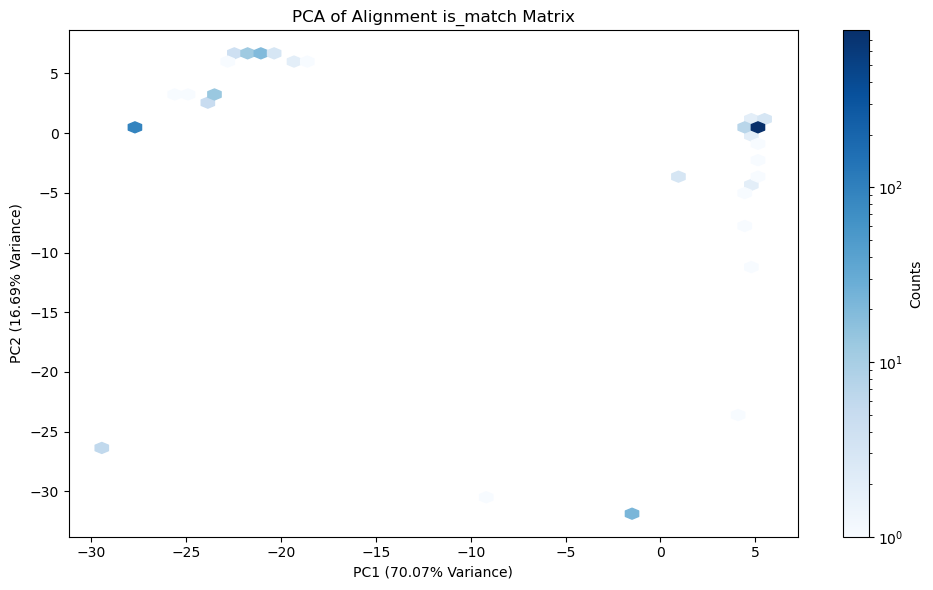

In [6]:
hexbin_fig = plot_pca_hexbin(matrix)
hexbin_fig.show()

/grid/kinney/home/desmara/.conda/envs/PacBio/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


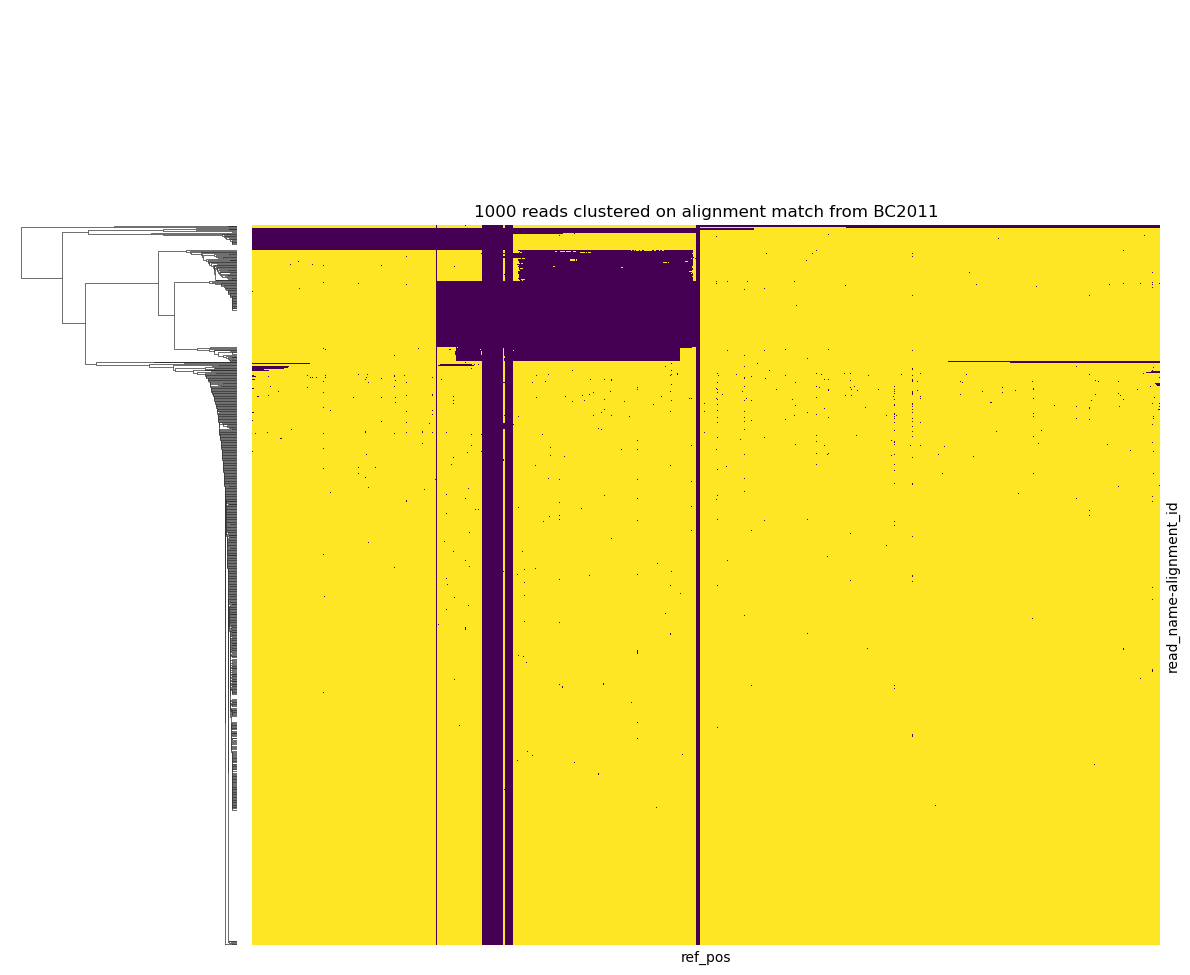

In [7]:
clustermap_grid = plot_clustermap(matrix.sample(1000))
plt.title("1000 reads clustered on alignment match from BC2011")
plt.suptitle("")
plt.show()